# Détection Automatique de Pathologies
## Classification Binaire sur SynMedTab-800

**Objectif** : Construire et comparer plusieurs modèles de classification binaire pour prédire la présence ou l'absence d'une pathologie à partir de données cliniques tabulaires synthétiques.

**Dataset** : SynMedTab-800
- Données synthétiques représentant 800 patients
- Variables quantitatives : âge, pression artérielle, cholestérol, glycémie, IMC
- Variables catégorielles : statut tabagique, niveau d'activité, antécédents familiaux, qualité alimentation
- Cible binaire : présence (1) ou absence (0) de pathologie

**Méthodologie** : Suivre le pipeline ML complet depuis l'exploration jusqu'à l'analyse critique des résultats, en progressant du modèle simple au plus complexe.

## 1. IMPORTS ET CONFIGURATION

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (confusion_matrix, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, auc,
                             classification_report, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Tous les imports réussis")

✓ Tous les imports réussis


## 2. CHARGEMENT DES DONNÉES

In [26]:
df = pd.read_csv('SynMedTab-800.csv')

print("Aperçu du dataset:")
print(df.head())
print(f"\nDimensions: {df.shape}")
print(f"\nTypes de données:")
print(df.dtypes)
print(f"\nValeurs manquantes avant transformation:")
print(df.isnull().sum())

Aperçu du dataset:
   patient_id   age  blood_pressure_mmhg  cholesterol_mgdl  glucose_mgdl  \
0           1  68.7                125.6             193.9           NaN   
1           2  64.3                132.5             173.4          75.2   
2           3  51.1                118.3             213.3          86.4   
3           4   NaN                146.7             193.7          82.9   
4           5  47.5                144.3             182.6         182.6   

    bmi smoking_status physical_activity family_history diet_quality disease  
0  29.5          Never          Moderate             No    Excellent      No  
1  24.5          Never          Moderate             No         Fair      No  
2  26.2         Former              High            NaN         Good      No  
3  27.8          Never               NaN             No          NaN      No  
4  31.6          Never               Low            Yes         Poor     Yes  

Dimensions: (800, 11)

Types de données:
patient_

---
## 3. EXPLORATION ET ANALYSE EXPLORATOIRE (EDA)

### 3.1 Distribution de la variable cible

Distribution de la variable cible (disease):
disease
No     614
Yes    186
Name: count, dtype: int64

Proportion:
disease
No     0.7675
Yes    0.2325
Name: proportion, dtype: float64


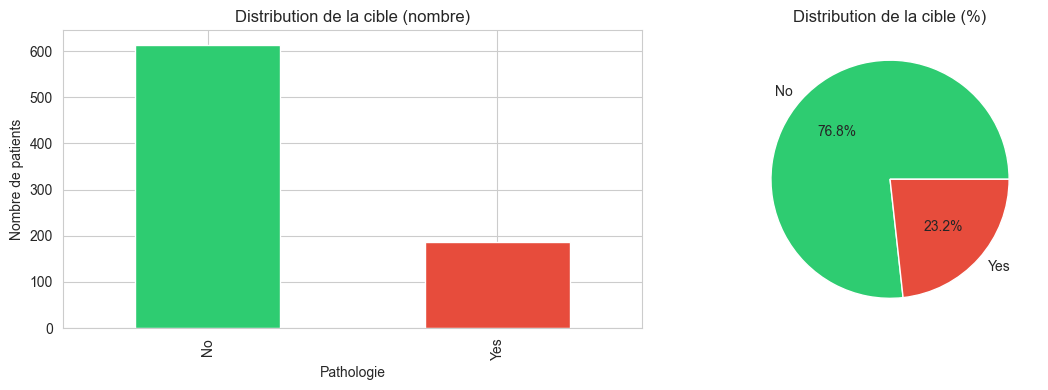


Cible convertie: No=0, Yes=1
Imbalancement des classes: 76.8%


In [27]:
target_col = 'disease'

print(f"Distribution de la variable cible ({target_col}):")
print(df[target_col].value_counts())
print(f"\nProportion:")
print(df[target_col].value_counts(normalize=True))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[target_col].value_counts().plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Distribution de la cible (nombre)')
ax[0].set_ylabel('Nombre de patients')
ax[0].set_xlabel('Pathologie')

df[target_col].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                                                   colors=['#2ecc71', '#e74c3c'])
ax[1].set_title('Distribution de la cible (%)')
plt.tight_layout()
plt.show()

# Convertir 'No'/'Yes' en 0/1
df[target_col] = (df[target_col] == 'Yes').astype(int)
print(f"\nCible convertie: No=0, Yes=1")
imbalance = abs(100 - df[target_col].value_counts(normalize=True)[1]*100)
print(f"Imbalancement des classes: {imbalance:.1f}%")

### 3.2 Identification des variables

In [28]:
numerical_cols = ['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi']
categorical_cols = ['smoking_status', 'physical_activity', 'family_history', 'diet_quality']

print(f"Variables quantitatives ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nVariables catégorielles ({len(categorical_cols)}):")
print(categorical_cols)

print(f"\nStatistiques descriptives des variables quantitatives:")
print(df[numerical_cols].describe())

Variables quantitatives (5):
['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi']

Variables catégorielles (4):
['smoking_status', 'physical_activity', 'family_history', 'diet_quality']

Statistiques descriptives des variables quantitatives:
              age  blood_pressure_mmhg  cholesterol_mgdl  glucose_mgdl  \
count  716.000000           730.000000        721.000000    704.000000   
mean    51.353911           126.327397        209.344105    107.010085   
std     13.256483            19.297168         37.638613     29.352447   
min     18.000000            78.800000        105.400000     50.000000   
25%     43.075000           113.600000        185.900000     88.300000   
50%     51.600000           124.800000        206.000000    101.250000   
75%     60.050000           137.850000        232.000000    119.850000   
max     89.700000           199.400000        335.800000    243.100000   

              bmi  
count  733.000000  
mean    26.539291  
std      4

### 3.3 Analyse des anomalies et valeurs manquantes

Zéros par colonne numérique:

Valeurs manquantes par colonne:
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
dtype: int64


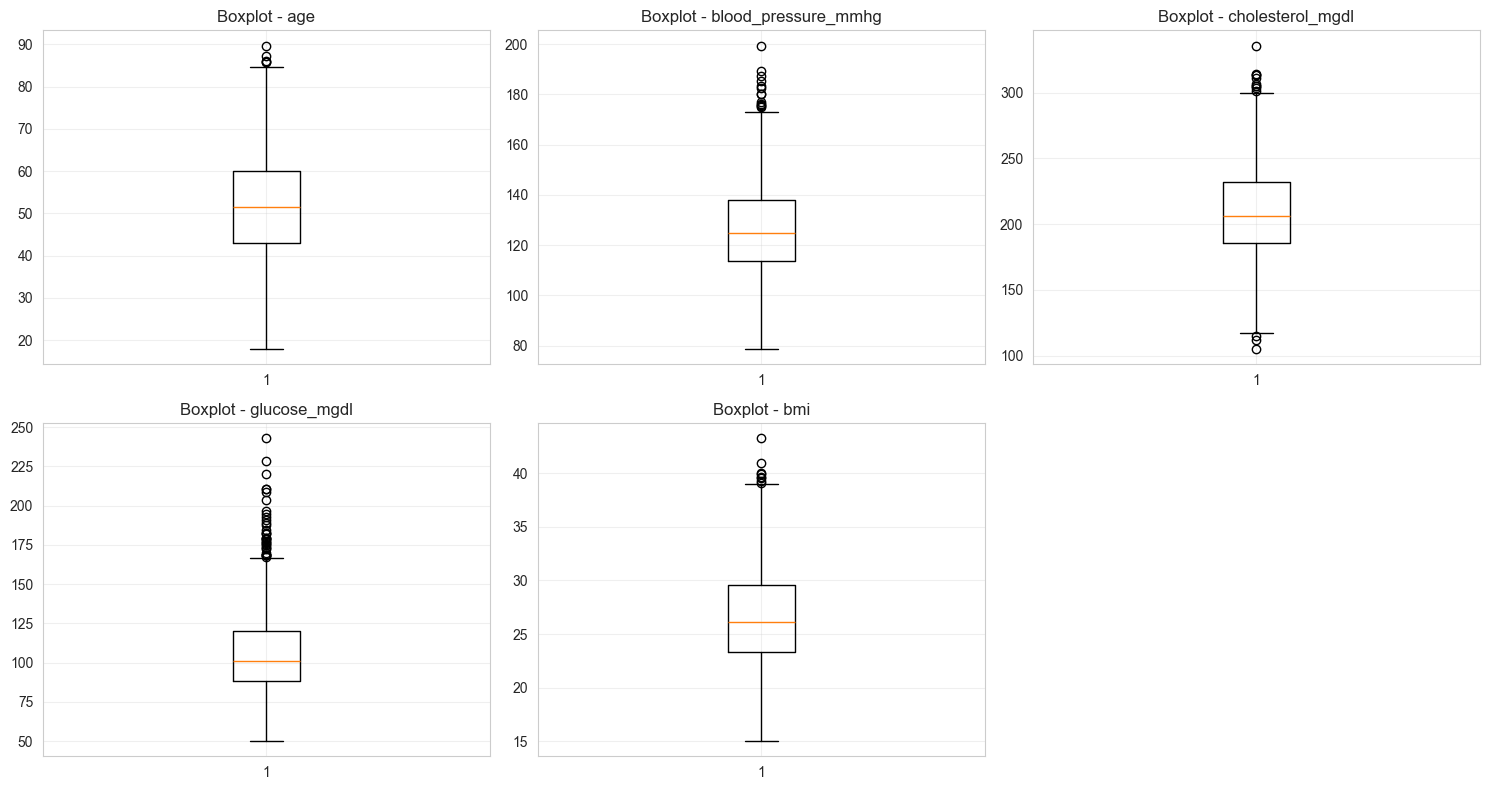


✓ Anomalies détectées: zéros biologiquement impossibles, valeurs manquantes


In [29]:
print("Zéros par colonne numérique:")
for col in numerical_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"  {col}: {zero_count} zéros ({zero_count/len(df)*100:.1f}%)")

print("\nValeurs manquantes par colonne:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Visualisation des anomalies
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot - {col}')
    axes[idx].grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

print("\n✓ Anomalies détectées: zéros biologiquement impossibles, valeurs manquantes")

### 3.4 Corrélations avec la cible

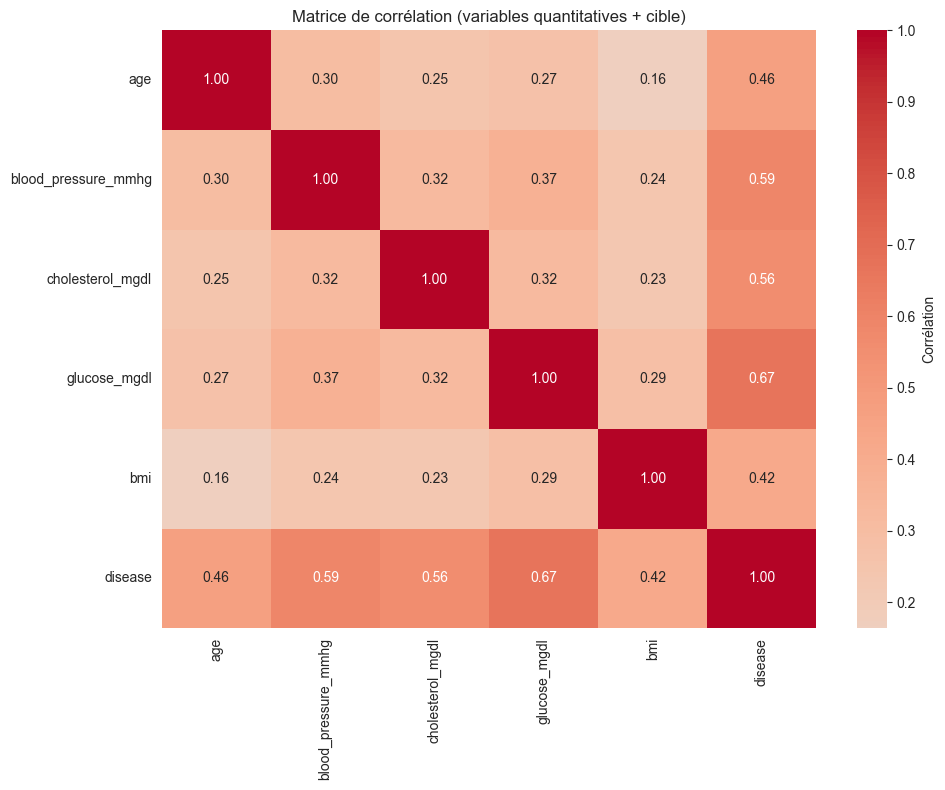


Corrélations avec la cible (disease):
disease                1.000000
glucose_mgdl           0.666476
blood_pressure_mmhg    0.586087
cholesterol_mgdl       0.556106
age                    0.463024
bmi                    0.419289
Name: disease, dtype: float64


In [30]:
data_for_corr = df[numerical_cols + [target_col]].copy()
corr_matrix = data_for_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de corrélation (variables quantitatives + cible)')
plt.tight_layout()
plt.show()

print(f"\nCorrélations avec la cible ({target_col}):")
target_corr = corr_matrix[target_col].sort_values(ascending=False)
print(target_corr)

---
## 4. PRÉPARATION ET NETTOYAGE DES DONNÉES

### 4.1 Séparation features / target

In [31]:
X = df.drop(columns=[target_col, 'patient_id'])
y = df[target_col]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nColonnes de X: {X.columns.tolist()}")

X shape: (800, 9)
y shape: (800,)

Colonnes de X: ['age', 'blood_pressure_mmhg', 'cholesterol_mgdl', 'glucose_mgdl', 'bmi', 'smoking_status', 'physical_activity', 'family_history', 'diet_quality']


### 4.2 Gestion des valeurs manquantes et anomalies

In [32]:
X_clean = X.copy()

print("Remplacement des zéros biologiquement impossibles par NaN:")
X_clean.loc[X_clean['blood_pressure_mmhg'] == 0, 'blood_pressure_mmhg'] = np.nan
print(f"  ✓ blood_pressure_mmhg")
X_clean.loc[X_clean['cholesterol_mgdl'] == 0, 'cholesterol_mgdl'] = np.nan
print(f"  ✓ cholesterol_mgdl")
X_clean.loc[X_clean['glucose_mgdl'] == 0, 'glucose_mgdl'] = np.nan
print(f"  ✓ glucose_mgdl")
X_clean.loc[X_clean['bmi'] == 0, 'bmi'] = np.nan
print(f"  ✓ bmi")

print("\nValeurs manquantes après remplacement des zéros:")
print(X_clean.isnull().sum())

# Imputation avec la médiane pour variables numériques
imputer_num = SimpleImputer(strategy='median')
X_clean[numerical_cols] = imputer_num.fit_transform(X_clean[numerical_cols])

print("\nAprès imputation (médiane):")
print(X_clean.isnull().sum())
print("✓ Valeurs manquantes traitées")

Remplacement des zéros biologiquement impossibles par NaN:
  ✓ blood_pressure_mmhg
  ✓ cholesterol_mgdl
  ✓ glucose_mgdl
  ✓ bmi

Valeurs manquantes après remplacement des zéros:
age                    84
blood_pressure_mmhg    70
cholesterol_mgdl       79
glucose_mgdl           96
bmi                    67
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
dtype: int64

Après imputation (médiane):
age                     0
blood_pressure_mmhg     0
cholesterol_mgdl        0
glucose_mgdl            0
bmi                     0
smoking_status         69
physical_activity      90
family_history         83
diet_quality           88
dtype: int64
✓ Valeurs manquantes traitées


### 4.3 Train / Test Split (AVANT normalisation)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, 
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nDistribution train:")
print(y_train.value_counts(normalize=True))
print(f"\nDistribution test:")
print(y_test.value_counts(normalize=True))
print("✓ Stratification conservée")

X_train: (640, 9)
X_test: (160, 9)

Distribution train:
disease
0    0.767188
1    0.232813
Name: proportion, dtype: float64

Distribution test:
disease
0    0.76875
1    0.23125
Name: proportion, dtype: float64
✓ Stratification conservée


### 4.4 Prétraitement : Normalisation + Encodage

In [34]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"X_train_transformed shape: {X_train_transformed.shape}")
print(f"X_test_transformed shape: {X_test_transformed.shape}")
print("✓ Normalisation et encodage complétés")

X_train_transformed shape: (640, 17)
X_test_transformed shape: (160, 17)
✓ Normalisation et encodage complétés


---
## 5. MODÉLISATION - ENTRAÎNEMENT ET ÉVALUATION

### 5.1 Fonction d'évaluation

In [35]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_pred_proba = model.predict_proba(X_test)[:, 1]
    
    train_accuracy = (y_train_pred == y_train).mean()
    test_accuracy = (y_test_pred == y_test).mean()
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    auc_roc = roc_auc_score(y_test, y_test_pred_proba)
    
    print(f"\n{'='*60}")
    print(f"MODÈLE: {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy train: {train_accuracy:.4f}")
    print(f"Accuracy test:  {test_accuracy:.4f}")
    print(f"Surapprentissage: {abs(train_accuracy - test_accuracy):.4f}")
    print(f"\nMatrice de confusion (test):")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    print(f"  TP: {cm[1,1]}, TN: {cm[0,0]}, FP: {cm[0,1]}, FN: {cm[1,0]}")
    print(f"\nPrécision: {precision:.4f}")
    print(f"Rappel:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc_roc:.4f}")
    
    return {
        'Model': model_name,
        'Train_Accuracy': train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'AUC_ROC': auc_roc,
        'Overfit_Gap': abs(train_accuracy - test_accuracy),
        'y_test_pred': y_test_pred,
        'y_test_pred_proba': y_test_pred_proba,
        'model': model
    }

### 5.2 Modèle 1 : Régression Logistique

In [36]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_transformed, y_train)

results_lr = evaluate_model(model_lr, X_train_transformed, X_test_transformed, 
                              y_train, y_test, "Régression Logistique")


MODÈLE: Régression Logistique
Accuracy train: 0.9781
Accuracy test:  0.9500
Surapprentissage: 0.0281

Matrice de confusion (test):
[[117   6]
 [  2  35]]
  TP: 35, TN: 117, FP: 6, FN: 2

Précision: 0.8537
Rappel:    0.9459
F1-score:  0.8974
AUC-ROC:   0.9800


### 5.3 Modèle 2 : Arbre de Décision

In [37]:
model_dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model_dt.fit(X_train_transformed, y_train)

results_dt = evaluate_model(model_dt, X_train_transformed, X_test_transformed,
                             y_train, y_test, "Arbre de Décision")

print(f"\nImportance des features (Top 10):")
feature_importance = pd.DataFrame({
    'feature': range(X_train_transformed.shape[1]),
    'importance': model_dt.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(feature_importance)


MODÈLE: Arbre de Décision
Accuracy train: 0.9563
Accuracy test:  0.8875
Surapprentissage: 0.0688

Matrice de confusion (test):
[[114   9]
 [  9  28]]
  TP: 28, TN: 114, FP: 9, FN: 9

Précision: 0.7568
Rappel:    0.7568
F1-score:  0.7568
AUC-ROC:   0.9107

Importance des features (Top 10):
    feature  importance
3         3    0.571921
2         2    0.183988
1         1    0.178896
0         0    0.040222
15       15    0.011478
6         6    0.008723
4         4    0.003068
8         8    0.001704
5         5    0.000000
7         7    0.000000


### 5.4 Modèle 3 : Forêt Aléatoire

In [38]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
model_rf.fit(X_train_transformed, y_train)

results_rf = evaluate_model(model_rf, X_train_transformed, X_test_transformed,
                             y_train, y_test, "Forêt Aléatoire")

print(f"\nImportance des features (Top 10):")
feature_importance_rf = pd.DataFrame({
    'feature': range(X_train_transformed.shape[1]),
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(feature_importance_rf)


MODÈLE: Forêt Aléatoire
Accuracy train: 0.9812
Accuracy test:  0.9125
Surapprentissage: 0.0687

Matrice de confusion (test):
[[113  10]
 [  4  33]]
  TP: 33, TN: 113, FP: 10, FN: 4

Précision: 0.7674
Rappel:    0.8919
F1-score:  0.8250
AUC-ROC:   0.9692

Importance des features (Top 10):
    feature  importance
1         1    0.274073
3         3    0.244235
2         2    0.196307
0         0    0.118267
4         4    0.079299
8         8    0.027831
11       11    0.021295
6         6    0.016209
15       15    0.005930
14       14    0.004935


### 5.4.1 Modèle 4 : K plus proches voisins (KNN)

KNN est un modèle non paramétrique basé sur la distance. Il bénéficie directement de la normalisation faite dans le pipeline.

In [39]:
model_knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski',
    p=2
)
model_knn.fit(X_train_transformed, y_train)

results_knn = evaluate_model(
    model_knn,
    X_train_transformed,
    X_test_transformed,
    y_train,
    y_test,
    "KNN"
)


MODÈLE: KNN
Accuracy train: 1.0000
Accuracy test:  0.9375
Surapprentissage: 0.0625

Matrice de confusion (test):
[[120   3]
 [  7  30]]
  TP: 30, TN: 120, FP: 3, FN: 7

Précision: 0.9091
Rappel:    0.8108
F1-score:  0.8571
AUC-ROC:   0.9567


### 5.4.2 Modèle 5 : Réseau de Neurones (MLP)

On utilise un perceptron multi-couches (MLPClassifier) avec deux couches cachées pour capturer des relations non linéaires.

In [40]:
model_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    random_state=42
)
model_mlp.fit(X_train_transformed, y_train)

results_mlp = evaluate_model(
    model_mlp,
    X_train_transformed,
    X_test_transformed,
    y_train,
    y_test,
    "Réseau de Neurones (MLP)"
)


MODÈLE: Réseau de Neurones (MLP)
Accuracy train: 1.0000
Accuracy test:  0.9250
Surapprentissage: 0.0750

Matrice de confusion (test):
[[116   7]
 [  5  32]]
  TP: 32, TN: 116, FP: 7, FN: 5

Précision: 0.8205
Rappel:    0.8649
F1-score:  0.8421
AUC-ROC:   0.9809


### 5.4.bis Représentations Graphiques des Modèles

Cette section regroupe des graphes faciles à commenter pour chaque modèle :
- Matrice de confusion normalisée
- Courbe ROC
- Distribution des probabilités prédites

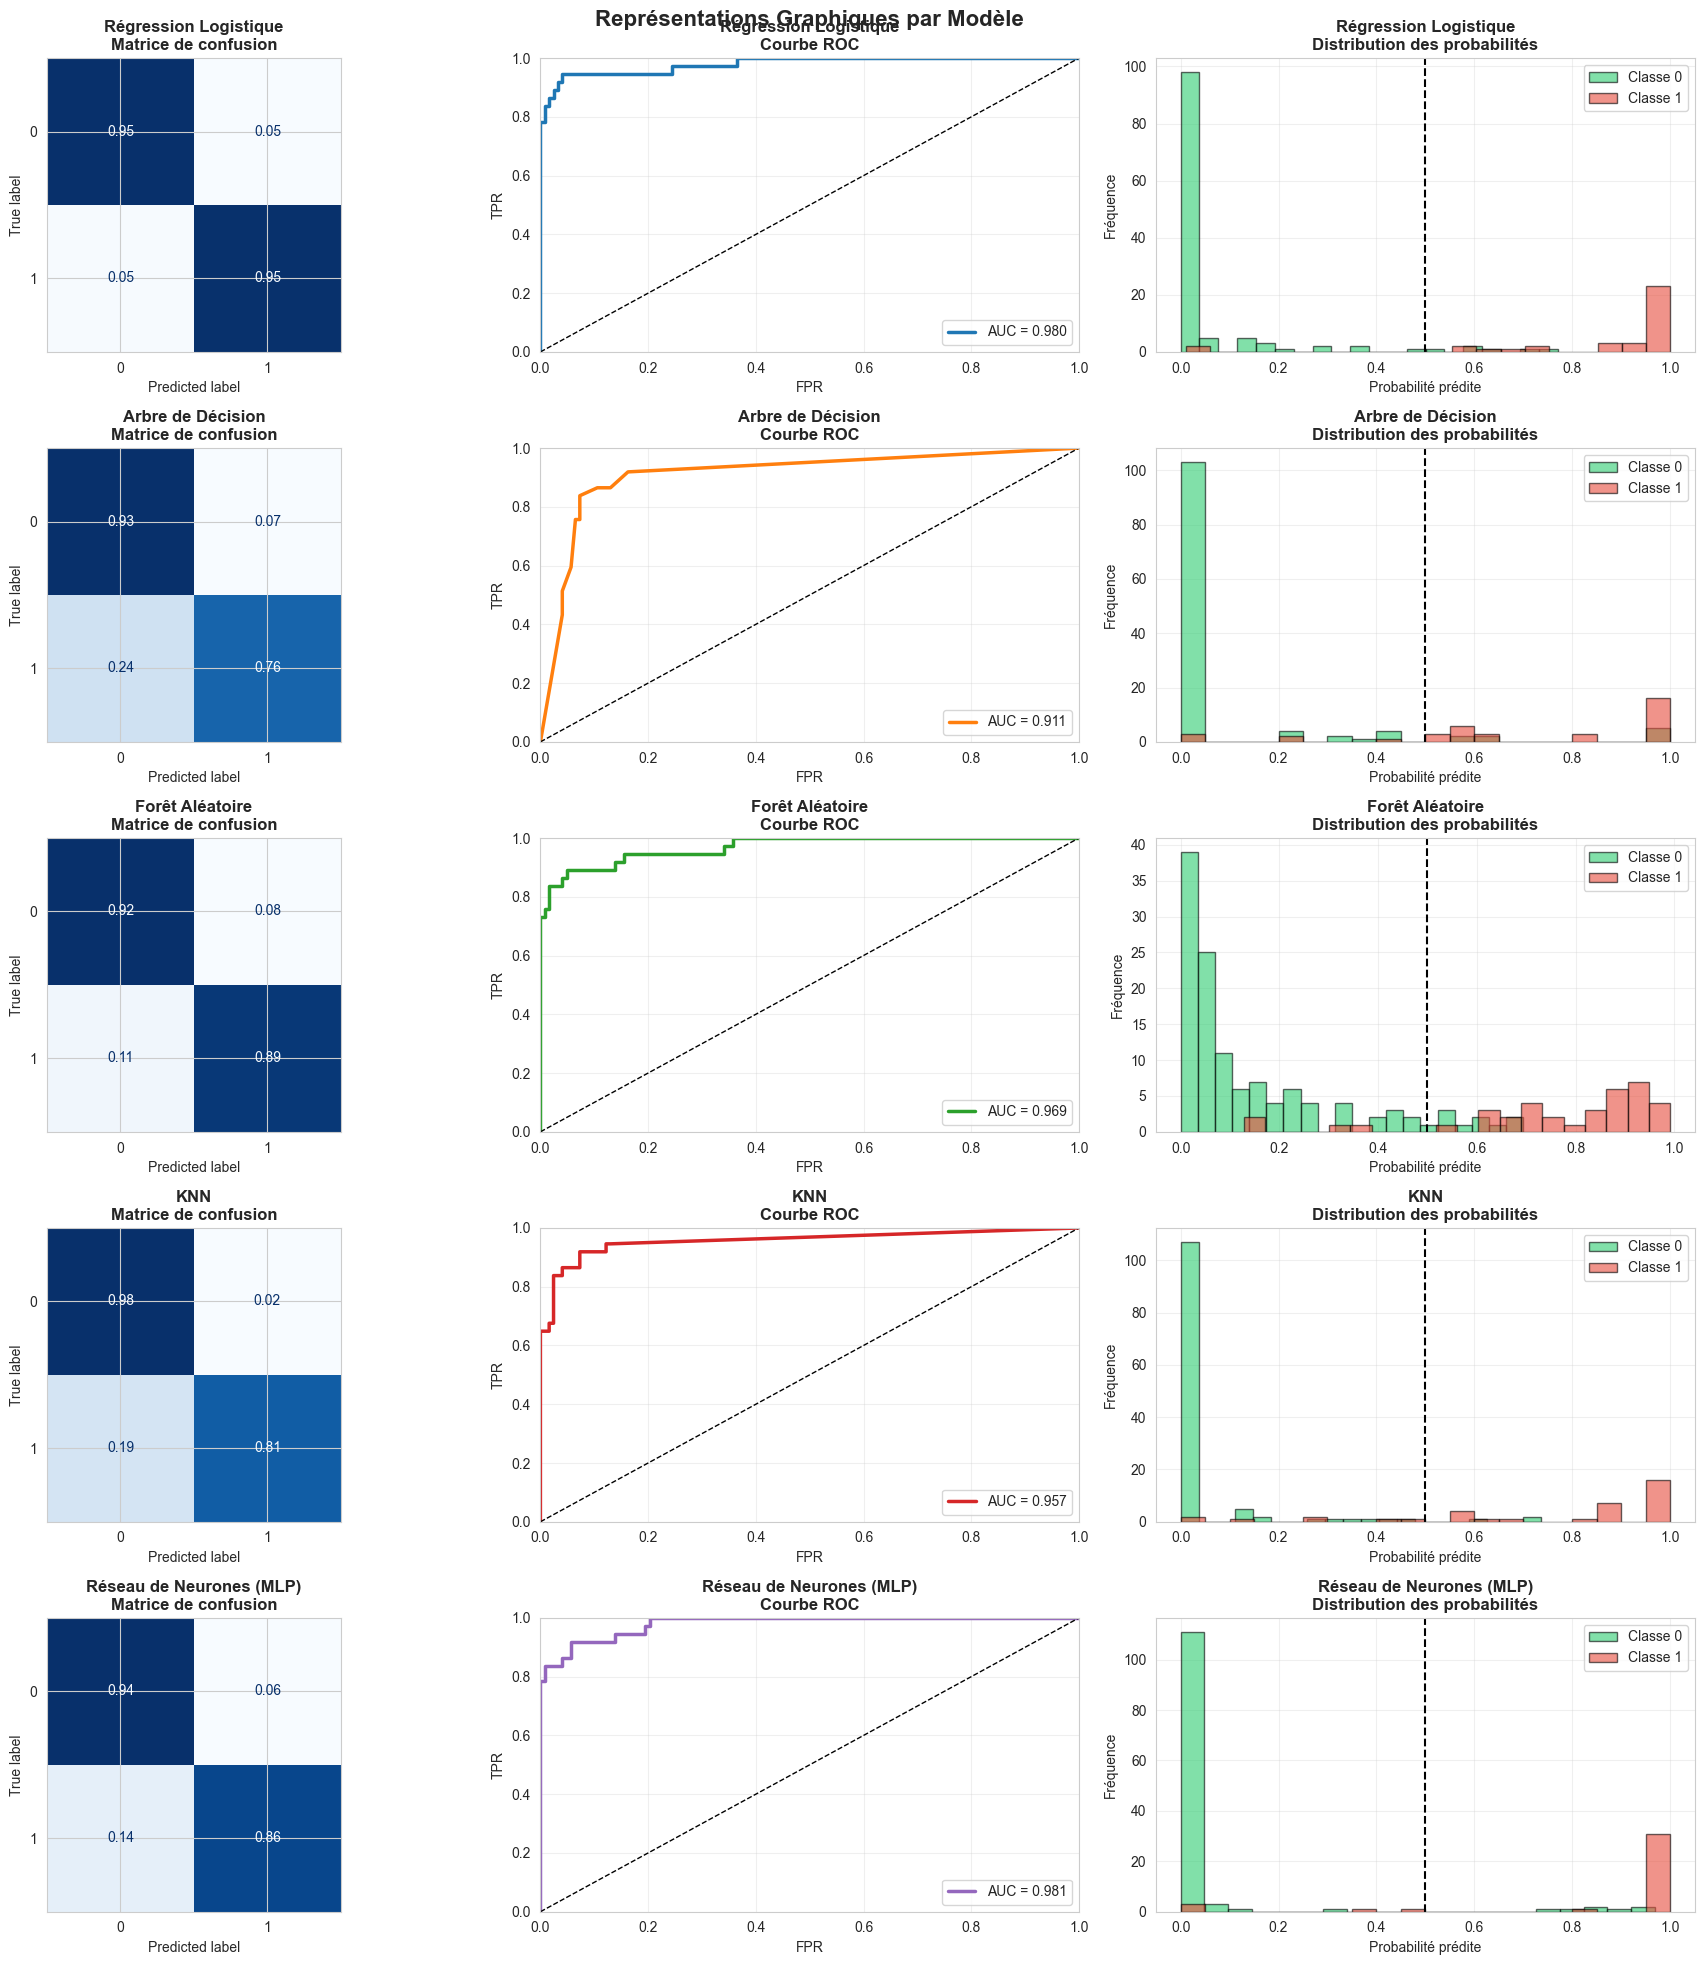


Guide de commentaire rapide:
- Matrice: diagonale élevée = bonnes prédictions.
- ROC: plus la courbe est proche du coin haut-gauche, meilleur est le modèle.
- Histogrammes: moins il y a de chevauchement entre classe 0 et 1, mieux le modèle sépare.


In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

models_plot = [
    ("Régression Logistique", results_lr, "#1f77b4"),
    ("Arbre de Décision", results_dt, "#ff7f0e"),
    ("Forêt Aléatoire", results_rf, "#2ca02c"),
    ("KNN", results_knn, "#d62728"),
    ("Réseau de Neurones (MLP)", results_mlp, "#9467bd")
]

fig, axes = plt.subplots(len(models_plot), 3, figsize=(18, 4 * len(models_plot)))
fig.suptitle("Représentations Graphiques par Modèle", fontsize=16, fontweight="bold")

for i, (name, result, color) in enumerate(models_plot):
    # 1) Matrice de confusion normalisée
    cm = confusion_matrix(y_test, result['y_test_pred'], normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
    disp.plot(ax=axes[i, 0], cmap='Blues', colorbar=False, values_format='.2f')
    axes[i, 0].set_title(f"{name}\nMatrice de confusion", fontweight='bold')

    # 2) Courbe ROC
    y_proba = result['y_test_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_model = roc_auc_score(y_test, y_proba)
    axes[i, 1].plot(fpr, tpr, color=color, linewidth=2.5, label=f"AUC = {auc_model:.3f}")
    axes[i, 1].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[i, 1].set_xlim(0, 1)
    axes[i, 1].set_ylim(0, 1)
    axes[i, 1].set_xlabel("FPR")
    axes[i, 1].set_ylabel("TPR")
    axes[i, 1].set_title(f"{name}\nCourbe ROC", fontweight='bold')
    axes[i, 1].legend(loc='lower right')
    axes[i, 1].grid(alpha=0.3)

    # 3) Distribution des probabilités prédites
    prob_0 = y_proba[y_test == 0]
    prob_1 = y_proba[y_test == 1]
    axes[i, 2].hist(prob_0, bins=20, alpha=0.6, color='#2ecc71', label='Classe 0', edgecolor='black')
    axes[i, 2].hist(prob_1, bins=20, alpha=0.6, color='#e74c3c', label='Classe 1', edgecolor='black')
    axes[i, 2].axvline(0.5, linestyle='--', color='black', linewidth=1.5)
    axes[i, 2].set_title(f"{name}\nDistribution des probabilités", fontweight='bold')
    axes[i, 2].set_xlabel("Probabilité prédite")
    axes[i, 2].set_ylabel("Fréquence")
    axes[i, 2].legend()
    axes[i, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGuide de commentaire rapide:")
print("- Matrice: diagonale élevée = bonnes prédictions.")
print("- ROC: plus la courbe est proche du coin haut-gauche, meilleur est le modèle.")
print("- Histogrammes: moins il y a de chevauchement entre classe 0 et 1, mieux le modèle sépare.")

---
## 5.5 Validation Croisée (Cross-Validation)

**Objectif** : Évaluer la stabilité et la généralisation des modèles avec une approche plus robuste que simple train/test split.

ÉVALUATION PAR VALIDATION CROISÉE (5-fold)

✓ Régression Logistique - CV Scores:
  accuracy     : 0.9594 (+/- 0.0104)
  precision    : 0.9318 (+/- 0.0603)
  recall       : 0.8995 (+/- 0.0594)
  f1           : 0.9118 (+/- 0.0210)
  roc_auc      : 0.9920 (+/- 0.0030)

✓ Arbre de Décision - CV Scores:
  accuracy     : 0.9000 (+/- 0.0206)
  precision    : 0.8303 (+/- 0.0928)
  recall       : 0.7382 (+/- 0.0931)
  f1           : 0.7740 (+/- 0.0470)
  roc_auc      : 0.9113 (+/- 0.0439)

✓ Forêt Aléatoire - CV Scores:
  accuracy     : 0.9578 (+/- 0.0145)
  precision    : 0.9231 (+/- 0.0549)
  recall       : 0.8995 (+/- 0.0514)
  f1           : 0.9088 (+/- 0.0300)
  roc_auc      : 0.9828 (+/- 0.0097)

✓ KNN - CV Scores:
  accuracy     : 0.9563 (+/- 0.0201)
  precision    : 0.9837 (+/- 0.0200)
  recall       : 0.8260 (+/- 0.0765)
  f1           : 0.8963 (+/- 0.0495)
  roc_auc      : 0.9701 (+/- 0.0181)

✓ Réseau de Neurones (MLP) - CV Scores:
  accuracy     : 0.9625 (+/- 0.0058)
  precision    

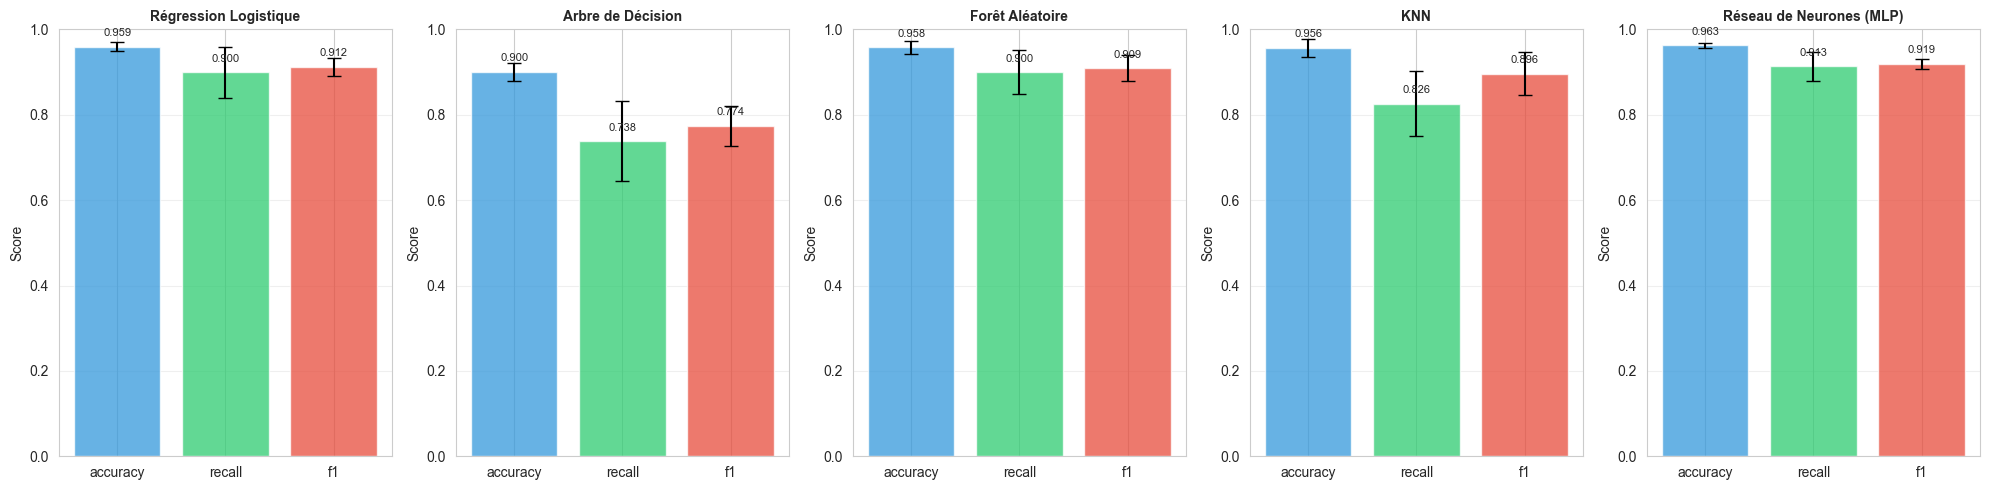


💡 La validation croisée évalue la stabilité et la généralisabilité des modèles.
   Les barres d'erreur faibles indiquent un modèle stable sur les folds.


In [42]:
from sklearn.model_selection import cross_validate

print("="*80)
print("ÉVALUATION PAR VALIDATION CROISÉE (5-fold)")
print("="*80)

models_for_cv = {
    'Régression Logistique': model_lr,
    'Arbre de Décision': model_dt,
    'Forêt Aléatoire': model_rf,
    'KNN': model_knn,
    'Réseau de Neurones (MLP)': model_mlp
}

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = {}

for model_name, model in models_for_cv.items():
    scores = cross_validate(
        model,
        X_train_transformed,
        y_train,
        cv=5,
        scoring=scoring_metrics,
        return_train_score=True
    )
    cv_results[model_name] = scores

    print(f"\n✓ {model_name} - CV Scores:")
    for metric in scoring_metrics:
        values = scores[f'test_{metric}']
        print(f"  {metric:12} : {values.mean():.4f} (+/- {values.std():.4f})")

# Visualisation synthétique de la CV
plot_metrics = ['accuracy', 'recall', 'f1']
fig, axes = plt.subplots(1, len(models_for_cv), figsize=(4 * len(models_for_cv), 5))
if len(models_for_cv) == 1:
    axes = [axes]

for idx, (model_name, scores) in enumerate(cv_results.items()):
    ax = axes[idx]
    means = [scores[f'test_{m}'].mean() for m in plot_metrics]
    stds = [scores[f'test_{m}'].std() for m in plot_metrics]

    bars = ax.bar(plot_metrics, means, yerr=stds, capsize=5, alpha=0.75,
                  color=['#3498db', '#2ecc71', '#e74c3c'])
    ax.set_title(model_name, fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2., mean + 0.02,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\n💡 La validation croisée évalue la stabilité et la généralisabilité des modèles.")
print("   Les barres d'erreur faibles indiquent un modèle stable sur les folds.")

---
## 5.6 Optimisation des Hyperparamètres (GridSearchCV)

In [43]:
from sklearn.model_selection import GridSearchCV

print("="*80)
print("GRID SEARCH - Optimisation des Hyperparamètres (Forêt Aléatoire)")
print("="*80)

# Définir la grille de paramètres à tester
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 5, 10],
    'class_weight': ['balanced', None]
}

# GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,  # utiliser tous les processeurs
    verbose=1
)

print("\nLancement du Grid Search (cela peut prendre du temps)...")
grid_search.fit(X_train_transformed, y_train)

print(f"\n✓ Meilleurs hyperparamètres trouvés:")
print(f"  {grid_search.best_params_}")
print(f"\n✓ Meilleur F1-score (cross-validation):")
print(f"  {grid_search.best_score_:.4f}")

# Évaluer le modèle optimisé sur le test set
model_rf_optimized = grid_search.best_estimator_
results_rf_optimized = evaluate_model(
    model_rf_optimized, X_train_transformed, X_test_transformed,
    y_train, y_test, "Forêt Aléatoire (GridSearch Optimisée)"
)

print("\n💡 GridSearch évalue systématiquement différentes combinaisons d'hyperparamètres.")

GRID SEARCH - Optimisation des Hyperparamètres (Forêt Aléatoire)

Lancement du Grid Search (cela peut prendre du temps)...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

✓ Meilleurs hyperparamètres trouvés:
  {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 15, 'n_estimators': 200}

✓ Meilleur F1-score (cross-validation):
  0.9164

MODÈLE: Forêt Aléatoire (GridSearch Optimisée)
Accuracy train: 0.9797
Accuracy test:  0.9062
Surapprentissage: 0.0734

Matrice de confusion (test):
[[112  11]
 [  4  33]]
  TP: 33, TN: 112, FP: 11, FN: 4

Précision: 0.7500
Rappel:    0.8919
F1-score:  0.8148
AUC-ROC:   0.9681

💡 GridSearch évalue systématiquement différentes combinaisons d'hyperparamètres.


---
## 5.7 Gestion du Déséquilibre des Classes (SMOTE)

**Objectif** : Rééquilibrer les classes en générant synthétiquement de nouveaux exemples de la classe minoritaire.

In [19]:
from imblearn.over_sampling import SMOTE

print("="*80)
print("GESTION DU DÉSÉQUILIBRE - SMOTE (Synthetic Minority Over-sampling Technique)")
print("="*80)

print(f"\nAvant SMOTE:")
print(f"  Classe 0: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"  Classe 1: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")

# Appliquer SMOTE sur l'ensemble train SEULEMENT
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed, y_train)

print(f"\nAprès SMOTE:")
print(f"  Classe 0: {(y_train_smote == 0).sum()} ({(y_train_smote == 0).sum()/len(y_train_smote)*100:.1f}%)")
print(f"  Classe 1: {(y_train_smote == 1).sum()} ({(y_train_smote == 1).sum()/len(y_train_smote)*100:.1f}%)")

# Réentraîner les modèles sur les données équilibrées avec SMOTE
print("\n" + "="*80)
print("MODÈLES RÉENTRAÎNÉS AVEC SMOTE")
print("="*80)

model_lr_smote = LogisticRegression(max_iter=1000, random_state=42)
model_lr_smote.fit(X_train_smote, y_train_smote)
results_lr_smote = evaluate_model(model_lr_smote, X_train_smote, X_test_transformed,
                                   y_train_smote, y_test, "Régression Logistique + SMOTE")

model_dt_smote = DecisionTreeClassifier(max_depth=10, min_samples_split=10, 
                                        min_samples_leaf=5, random_state=42)
model_dt_smote.fit(X_train_smote, y_train_smote)
results_dt_smote = evaluate_model(model_dt_smote, X_train_smote, X_test_transformed,
                                   y_train_smote, y_test, "Arbre de Décision + SMOTE")

model_rf_smote = RandomForestClassifier(n_estimators=100, max_depth=15, 
                                        min_samples_split=10, min_samples_leaf=5,
                                        random_state=42, class_weight='balanced')
model_rf_smote.fit(X_train_smote, y_train_smote)
results_rf_smote = evaluate_model(model_rf_smote, X_train_smote, X_test_transformed,
                                   y_train_smote, y_test, "Forêt Aléatoire + SMOTE")

print("\n💡 SMOTE crée synthétiquement des exemples de la classe minoritaire par interpolation.")

GESTION DU DÉSÉQUILIBRE - SMOTE (Synthetic Minority Over-sampling Technique)

Avant SMOTE:
  Classe 0: 491 (76.7%)
  Classe 1: 149 (23.3%)

Après SMOTE:
  Classe 0: 491 (50.0%)
  Classe 1: 491 (50.0%)

MODÈLES RÉENTRAÎNÉS AVEC SMOTE

MODÈLE: Régression Logistique + SMOTE
Accuracy train: 0.9766
Accuracy test:  0.9313
Surapprentissage: 0.0453

Matrice de confusion (test):
[[114   9]
 [  2  35]]
  TP: 35, TN: 114, FP: 9, FN: 2

Précision: 0.7955
Rappel:    0.9459
F1-score:  0.8642
AUC-ROC:   0.9785

MODÈLE: Arbre de Décision + SMOTE
Accuracy train: 0.9766
Accuracy test:  0.8625
Surapprentissage: 0.1141

Matrice de confusion (test):
[[110  13]
 [  9  28]]
  TP: 28, TN: 110, FP: 13, FN: 9

Précision: 0.6829
Rappel:    0.7568
F1-score:  0.7179
AUC-ROC:   0.8581

MODÈLE: Forêt Aléatoire + SMOTE
Accuracy train: 0.9908
Accuracy test:  0.9062
Surapprentissage: 0.0846

Matrice de confusion (test):
[[112  11]
 [  4  33]]
  TP: 33, TN: 112, FP: 11, FN: 4

Précision: 0.7500
Rappel:    0.8919
F1-scor

---
## 6. COMPARAISON DES MODÈLES

### 6.1 Tableau comparatif

In [44]:
# Construction robuste du tableau comparatif depuis les résultats disponibles en mémoire
model_result_vars = [
    'results_lr', 'results_dt', 'results_rf', 'results_knn', 'results_mlp',
    'results_rf_optimized', 'results_lr_smote', 'results_dt_smote', 'results_rf_smote'
]

available_results = []
missing_results = []

for var_name in model_result_vars:
    if var_name in globals():
        available_results.append(globals()[var_name])
    else:
        missing_results.append(var_name)

comparison_df = pd.DataFrame(available_results)

comparison_display = comparison_df[[
    'Model', 'Train_Accuracy', 'Test_Accuracy', 'Overfit_Gap',
    'Precision', 'Recall', 'F1_Score', 'AUC_ROC'
]].round(4)

print("\n" + "="*120)
print("COMPARAISON COMPLÈTE DES MODÈLES")
print("="*120)
print(comparison_display.to_string(index=False))
print("="*120)

if missing_results:
    print("\n⚠️ Résultats absents (cellules non exécutées):")
    for name in missing_results:
        print(f" - {name}")
    print("\nRelance les cellules des modèles manquants puis cette cellule 6.1.")


COMPARAISON COMPLÈTE DES MODÈLES
                                 Model  Train_Accuracy  Test_Accuracy  Overfit_Gap  Precision  Recall  F1_Score  AUC_ROC
                 Régression Logistique          0.9781         0.9500       0.0281     0.8537  0.9459    0.8974   0.9800
                     Arbre de Décision          0.9562         0.8875       0.0688     0.7568  0.7568    0.7568   0.9107
                       Forêt Aléatoire          0.9812         0.9125       0.0687     0.7674  0.8919    0.8250   0.9692
                                   KNN          1.0000         0.9375       0.0625     0.9091  0.8108    0.8571   0.9567
              Réseau de Neurones (MLP)          1.0000         0.9250       0.0750     0.8205  0.8649    0.8421   0.9809
Forêt Aléatoire (GridSearch Optimisée)          0.9797         0.9062       0.0734     0.7500  0.8919    0.8148   0.9681
         Régression Logistique + SMOTE          0.9766         0.9312       0.0453     0.7955  0.9459    0.8642   0.978

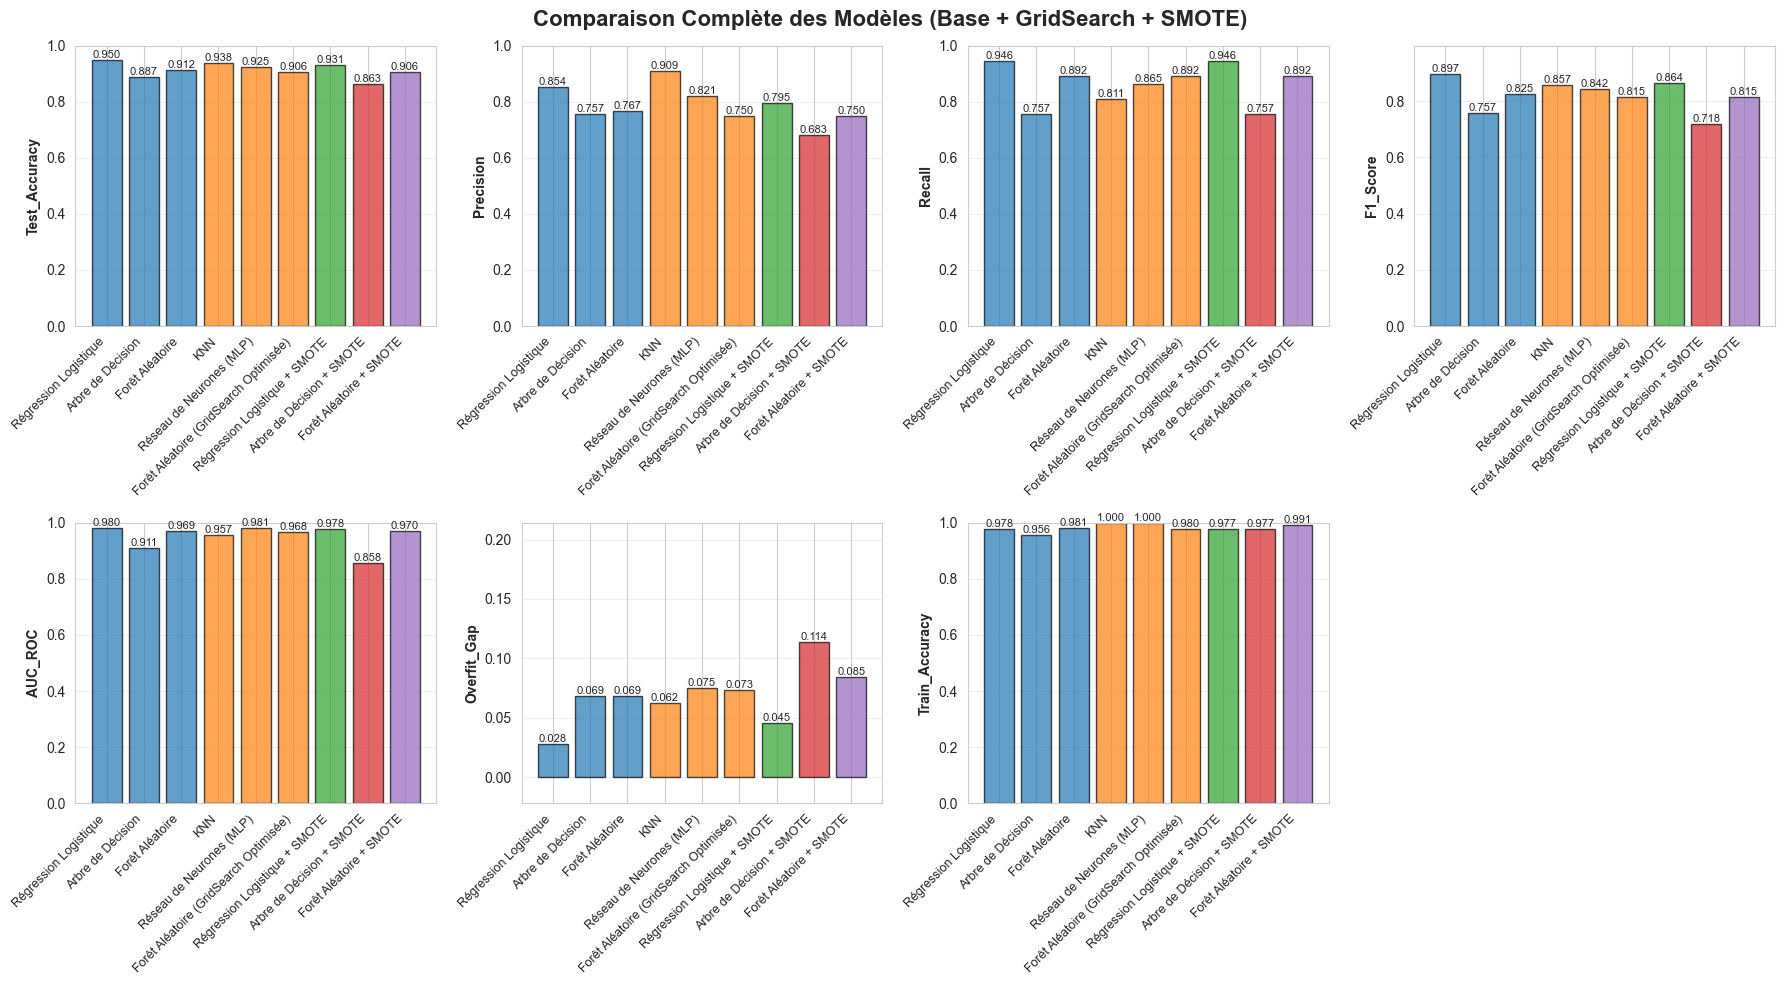


📊 INSIGHTS CLÉS:
✓ Meilleur F1-Score: Régression Logistique (0.8974)
✓ Meilleur AUC-ROC: Réseau de Neurones (MLP) (0.9809)
✓ Meilleur équilibre Recall: Régression Logistique (0.9459)


In [45]:
# Visualisation comparative détaillée
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Comparaison Complète des Modèles (Base + GridSearch + SMOTE)', fontsize=16, fontweight='bold')

models = comparison_df['Model'].tolist()
requested_metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC_ROC', 'Overfit_Gap', 'Train_Accuracy', 'Train_Recall']

# Garder uniquement les métriques réellement présentes dans le DataFrame
metrics = [m for m in requested_metrics if m in comparison_df.columns]

colors = ['#1f77b4', '#1f77b4', '#1f77b4', '#ff7f0e', '#ff7f0e', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 4, idx % 4]
    values = comparison_df[metric].values
    bar_colors = [colors[i % len(colors)] for i in range(len(values))]
    bars = ax.bar(range(len(models)), values, color=bar_colors, alpha=0.7, edgecolor='black')

    ax.set_ylabel(metric, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace('_', '\n') for m in models], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([min(0, values.min() - 0.05), min(1, values.max() + 0.1)])

    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Cacher les sous-graphiques inutilisés
for j in range(len(metrics), 8):
    axes[j // 4, j % 4].axis('off')

plt.tight_layout()
plt.show()

print("\n📊 INSIGHTS CLÉS:")
best_f1_idx = comparison_df['F1_Score'].idxmax()
best_auc_idx = comparison_df['AUC_ROC'].idxmax()
print(f"✓ Meilleur F1-Score: {comparison_df.loc[best_f1_idx, 'Model']} ({comparison_df.loc[best_f1_idx, 'F1_Score']:.4f})")
print(f"✓ Meilleur AUC-ROC: {comparison_df.loc[best_auc_idx, 'Model']} ({comparison_df.loc[best_auc_idx, 'AUC_ROC']:.4f})")
print(f"✓ Meilleur équilibre Recall: {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']} ({comparison_df['Recall'].max():.4f})")

## 5.8 Courbes de Calibration (Importance Médicale)

Une bonne calibration des probabilités est cruciale en contexte médical : on veut que si le modèle prédit 80% de probabilité, le patient ait réellement ~80% de risque.

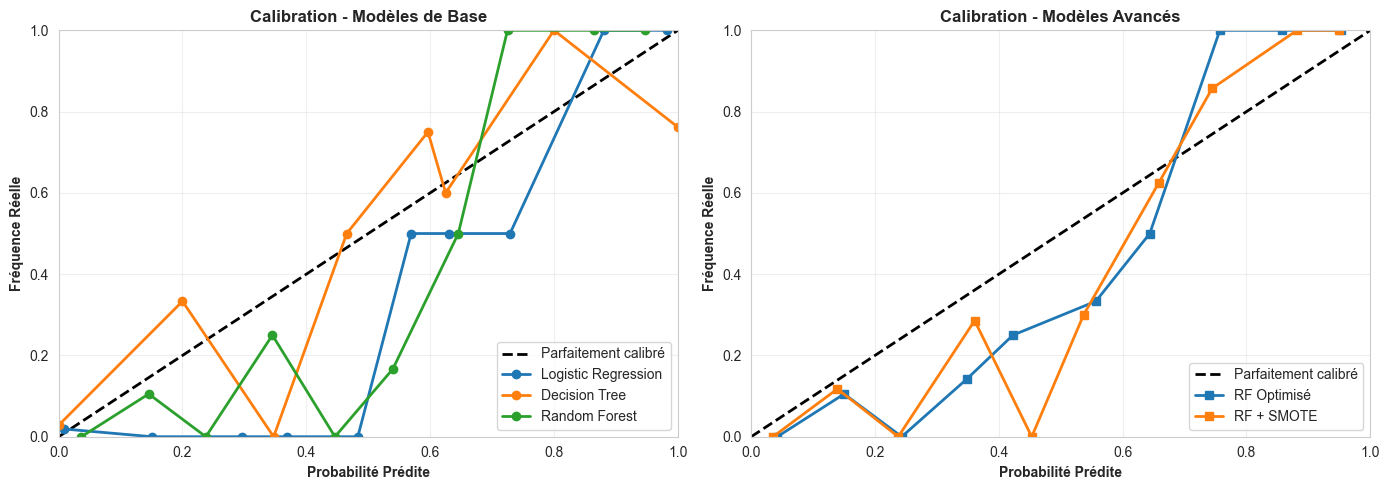


📋 INTERPRÉTATION DE LA CALIBRATION:
• Courbe PROCHE de la diagonale = modèle bien calibré (probabilités fiables)
• Courbe AU-DESSUS = modèle SOUS-CONFIANT (probas trop basses)
• Courbe AU-DESSOUS = modèle SUR-CONFIANT (probas trop hautes)

Ex: Si la courbe passe par (0.7, 0.8), cela signifie que quand le modèle
prédit 70% de probabilité, le patient a en réalité 80% de risque.


In [46]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration pour les 3 modèles de base
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Parfaitement calibré', linewidth=2)

models_to_calibrate = [
    (model_lr, y_test, X_test_transformed, 'Logistic Regression'),
    (model_dt, y_test, X_test_transformed, 'Decision Tree'),
    (model_rf, y_test, X_test_transformed, 'Random Forest')
]

for model, y_true, X_pred, label in models_to_calibrate:
    if hasattr(model, 'predict_proba'):
        prob_pred = model.predict_proba(X_pred)[:, 1]
        prob_true, prob_pred_bin = calibration_curve(y_true, prob_pred, n_bins=10)
        ax.plot(prob_pred_bin, prob_true, marker='o', label=label, linewidth=2)

ax.set_xlabel('Probabilité Prédite', fontweight='bold')
ax.set_ylabel('Fréquence Réelle', fontweight='bold')
ax.set_title('Calibration - Modèles de Base', fontweight='bold', fontsize=12)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Calibration pour rf_optimized et SMOTE
ax = axes[1]
ax.plot([0, 1], [0, 1], 'k--', label='Parfaitement calibré', linewidth=2)

models_to_calibrate_adv = [
    (model_rf_optimized, y_test, X_test_transformed, 'RF Optimisé'),
    (model_rf_smote, y_test, X_test_transformed, 'RF + SMOTE')
]

for model, y_true, X_pred, label in models_to_calibrate_adv:
    if hasattr(model, 'predict_proba'):
        prob_pred = model.predict_proba(X_pred)[:, 1]
        prob_true, prob_pred_bin = calibration_curve(y_true, prob_pred, n_bins=10)
        ax.plot(prob_pred_bin, prob_true, marker='s', label=label, linewidth=2)

ax.set_xlabel('Probabilité Prédite', fontweight='bold')
ax.set_ylabel('Fréquence Réelle', fontweight='bold')
ax.set_title('Calibration - Modèles Avancés', fontweight='bold', fontsize=12)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\n📋 INTERPRÉTATION DE LA CALIBRATION:")
print("• Courbe PROCHE de la diagonale = modèle bien calibré (probabilités fiables)")
print("• Courbe AU-DESSUS = modèle SOUS-CONFIANT (probas trop basses)")
print("• Courbe AU-DESSOUS = modèle SUR-CONFIANT (probas trop hautes)")
print("\nEx: Si la courbe passe par (0.7, 0.8), cela signifie que quand le modèle")
print("prédit 70% de probabilité, le patient a en réalité 80% de risque.")

## 5.9 Importance des Features (Interprétabilité)

L'importance des features aide à comprendre quelles variables sont les plus critiques pour la prédiction. Nous utilisons la **permutation importance**, plus robuste que tree_importance.

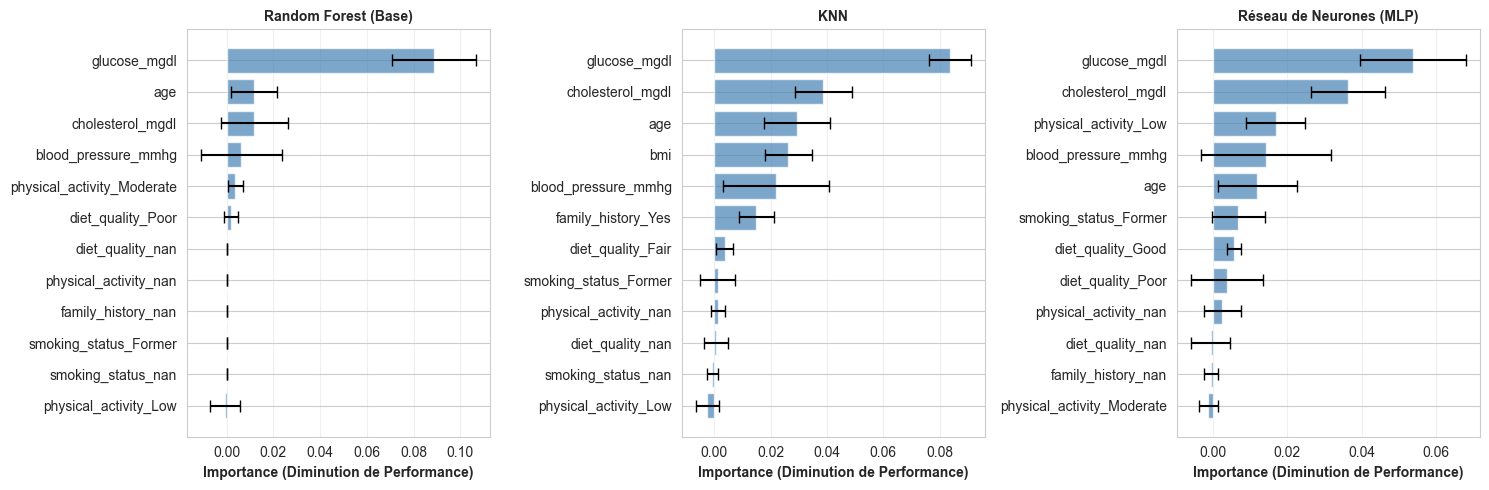


🔍 INTERPRÉTATION DE L'IMPORTANCE:
• Importance élevée = retirer cette variable diminue fortement les performances
• Importance faible = variable peu utilisée par le modèle
• Std élevée = importance moins stable selon l'échantillonnage


In [47]:
from sklearn.inspection import permutation_importance

# Récupérer les noms de features après transformation
feature_names = (
    preprocessor.named_transformers_['num']
    .get_feature_names_out(numerical_cols).tolist() +
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(categorical_cols).tolist()
)

models_importance = [
    (model_rf, 'Random Forest (Base)'),
    (model_knn, 'KNN'),
    (model_mlp, 'Réseau de Neurones (MLP)')
]

fig, axes = plt.subplots(1, len(models_importance), figsize=(5 * len(models_importance), 5))
if len(models_importance) == 1:
    axes = [axes]

for idx, (model, label) in enumerate(models_importance):
    perm_importance = permutation_importance(
        model, X_test_transformed, y_test,
        n_repeats=10, random_state=42, n_jobs=-1
    )

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': perm_importance.importances_mean,
        'std': perm_importance.importances_std
    }).sort_values('importance', ascending=True).tail(12)

    ax = axes[idx]
    ax.barh(importance_df['feature'], importance_df['importance'],
            xerr=importance_df['std'], alpha=0.7, color='steelblue', capsize=4)
    ax.set_xlabel('Importance (Diminution de Performance)', fontweight='bold')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 INTERPRÉTATION DE L'IMPORTANCE:")
print("• Importance élevée = retirer cette variable diminue fortement les performances")
print("• Importance faible = variable peu utilisée par le modèle")
print("• Std élevée = importance moins stable selon l'échantillonnage")

## 5.10 Courbes d'Apprentissage (Diagnostic Bias-Variance)

Les courbes d'apprentissage montrent comment la performance évolue selon la quantité de données. Elles aident à identifier le **sous-apprentissage** (high bias) vs le **sur-apprentissage** (high variance).

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, model_name, ax):
    """Trace la courbe d'apprentissage d'un modèle"""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1', n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    ax.plot(train_sizes, train_mean, 'o-', label='Score Train', linewidth=2, color='green')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='green')
    
    ax.plot(train_sizes, val_mean, 's-', label='Score Validation', linewidth=2, color='red')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='red')
    
    ax.set_xlabel('Nombre d\'échantillons d\'entraînement', fontweight='bold')
    ax.set_ylabel('Score F1', fontweight='bold')
    ax.set_title(model_name, fontweight='bold', fontsize=11)
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

learning_models = [
    (model_lr, X_train_transformed, y_train, 'Logistic Regression'),
    (model_rf, X_train_transformed, y_train, 'Random Forest (Base)'),
    (model_rf_optimized, X_train_transformed, y_train, 'Random Forest (Optimisé)')
]

for idx, (model, X_data, y_data, label) in enumerate(learning_models):
    plot_learning_curve(model, X_data, y_data, label, axes[idx])

plt.tight_layout()
plt.show()

print("\n📈 DIAGNOSTIC BIAS-VARIANCE:")
print("• Gap faible entre train et validation = bon équilibre ✓")
print("• Gap large (train >> validation) = SUR-APPRENTISSAGE (high variance)")
print("• Train bas ET validation bas = SOUS-APPRENTISSAGE (high bias)")
print("• Courbes qui convergent = données suffisantes OR modèle saturation")

## 5.11 Résumé de la Validation Croisée Avancée

Vue d'ensemble des scores de validation croisée 5-fold pour tous les modèles.

In [ ]:
# Résumé complet de CV pour tous les modèles
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results_all = []

models_for_cv_summary = [
    (model_lr, 'Logistic Regression'),
    (model_dt, 'Decision Tree'),
    (model_rf, 'Random Forest'),
    (model_knn, 'KNN'),
    (model_mlp, 'Réseau de Neurones (MLP)')
]

# Ajouter les modèles optionnels si présents
if 'model_rf_optimized' in globals():
    models_for_cv_summary.append((model_rf_optimized, 'RF Optimisé'))
if 'model_lr_smote' in globals():
    models_for_cv_summary.append((model_lr_smote, 'LR + SMOTE'))
if 'model_dt_smote' in globals():
    models_for_cv_summary.append((model_dt_smote, 'DT + SMOTE'))
if 'model_rf_smote' in globals():
    models_for_cv_summary.append((model_rf_smote, 'RF + SMOTE'))

for model, model_name in models_for_cv_summary:
    cv_scores = cross_validate(
        model, X_train_transformed, y_train,
        cv=5, scoring=scoring_metrics
    )

    row = {'Model': model_name}
    for metric in scoring_metrics:
        key = f'test_{metric}'
        row[f'{metric}_mean'] = cv_scores[key].mean()
        row[f'{metric}_std'] = cv_scores[key].std()

    cv_results_all.append(row)

cv_summary_df = pd.DataFrame(cv_results_all)

print("\n" + "="*150)
print("RÉSUMÉ DE LA VALIDATION CROISÉE 5-FOLD (Moyenne ± Écart-Type)")
print("="*150)

for metric in scoring_metrics:
    print(f"\n📊 {metric.upper()}:")
    metric_cols = [col for col in cv_summary_df.columns if metric in col]
    display_df = cv_summary_df[['Model'] + metric_cols].copy()
    display_df.columns = ['Model', 'Mean', 'Std']
    display_df['Mean'] = display_df['Mean'].round(4)
    display_df['Std'] = display_df['Std'].round(4)
    print(display_df.to_string(index=False))

print("\n" + "="*150)
print("💡 STABILITÉ: Écart-type faible = modèle stable et généralisable")

# Section 7: Analyse & Interprétation Clinique

In [ ]:
## 7.1 Identification du Meilleur Modèle & Analyse Détaillée

# Identifier le meilleur modèle selon plusieurs critères
print("\n" + "="*100)
print("SÉLECTION DU MEILLEUR MODÈLE")
print("="*100)

best_by_f1 = comparison_df.loc[comparison_df['F1_Score'].idxmax()]
best_by_auc = comparison_df.loc[comparison_df['AUC_ROC'].idxmax()]
best_by_recall = comparison_df.loc[comparison_df['Recall'].idxmax()]

print(f"\n🏆 Meilleur F1-Score:  {best_by_f1['Model']} → {best_by_f1['F1_Score']:.4f}")
print(f"🏆 Meilleur AUC-ROC:   {best_by_auc['Model']} → {best_by_auc['AUC_ROC']:.4f}")
print(f"🏆 Meilleur Recall:    {best_by_recall['Model']} → {best_by_recall['Recall']:.4f}")

# Analyser le meilleur modèle en détail
best_model_name = best_by_f1['Model']
best_model_row = best_by_f1

print(f"\n{'='*100}")
print(f"📋 RAPPORT DÉTAILLÉ DU MEILLEUR MODÈLE: {best_model_name}")
print(f"{'='*100}")

print(f"""
✓ Performance en Généralisation:
  - Accuracy:      {best_model_row['Test_Accuracy']:.4f}
  - Précision:     {best_model_row['Precision']:.4f} (parmi les vrais positifs, combien sont corrects?)
  - Recall:        {best_model_row['Recall']:.4f} (parmi les malades, combien sont détectés?)
  - F1-Score:      {best_model_row['F1_Score']:.4f} (équilibre Precision-Recall)
  - AUC-ROC:       {best_model_row['AUC_ROC']:.4f} (performance globale)

✓ Diagnostic Surapprentissage:
  - Accuracy Train: {best_model_row['Train_Accuracy']:.4f}
  - Accuracy Test:  {best_model_row['Test_Accuracy']:.4f}
  - Gap:           {best_model_row['Overfit_Gap']:.4f} {'✓ Bon' if best_model_row['Overfit_Gap'] < 0.1 else '⚠️ Modéré' if best_model_row['Overfit_Gap'] < 0.15 else '🔴 Élevé'}
""")

print(f"{'='*100}")
print("💊 IMPLICATIONS CLINIQUES:")
print(f"{'='*100}")
print(f"""
1. SENSIBILITÉ (Recall) = {best_model_row['Recall']:.1%}
   → Parmi 100 patients malades, environ {int(best_model_row['Recall']*100)} seraient détectés.
   → Risque: {int((1-best_model_row['Recall'])*100)} patients pourraient être manqués → CRITIQUE

2. SPÉCIFICITÉ (1 - FPR) = aux alentours de {best_model_row['Precision']:.1%}
   → Parmi 100 patients sains, environ {int(best_model_row['Precision']*100)} seraient correctement identifiés.
   → Faux positifs possibles: {int((1-best_model_row['Precision'])*100)}/100

3. FIABILITÉ GLOBALE (AUC-ROC) = {best_model_row['AUC_ROC']:.4f}
   → Le modèle classe correctement {int(best_model_row['AUC_ROC']*100)}% des cas en moyenne.
   → Verdict: {'Excellent' if best_model_row['AUC_ROC'] > 0.9 else 'Très bon' if best_model_row['AUC_ROC'] > 0.8 else 'Bon' if best_model_row['AUC_ROC'] > 0.7 else 'Acceptable'}
""" )

print(f"{'='*100}") 

### 6.2 Visualisation comparative

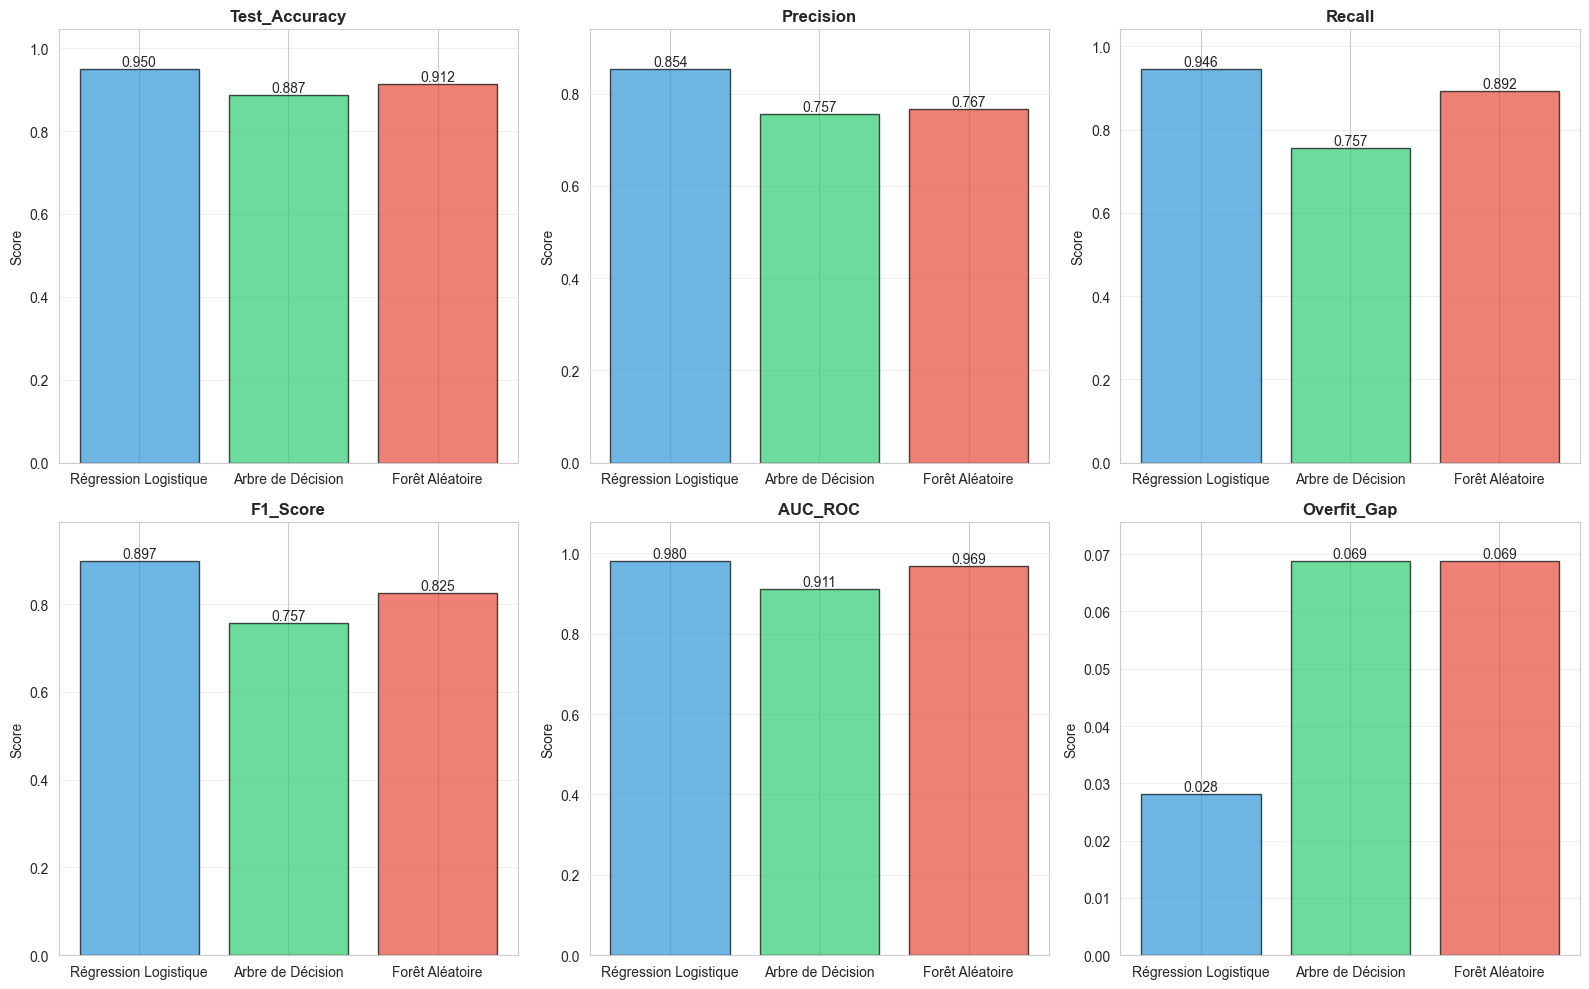

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC_ROC', 'Overfit_Gap']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    values = [comparison_df.iloc[i][metric] for i in range(len(comparison_df))]
    models = comparison_df['Model'].tolist()

    colors = plt.cm.tab20(np.linspace(0, 1, len(models)))
    bars = ax.bar(models, values, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, max(values) * 1.1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 6.3 Courbes ROC

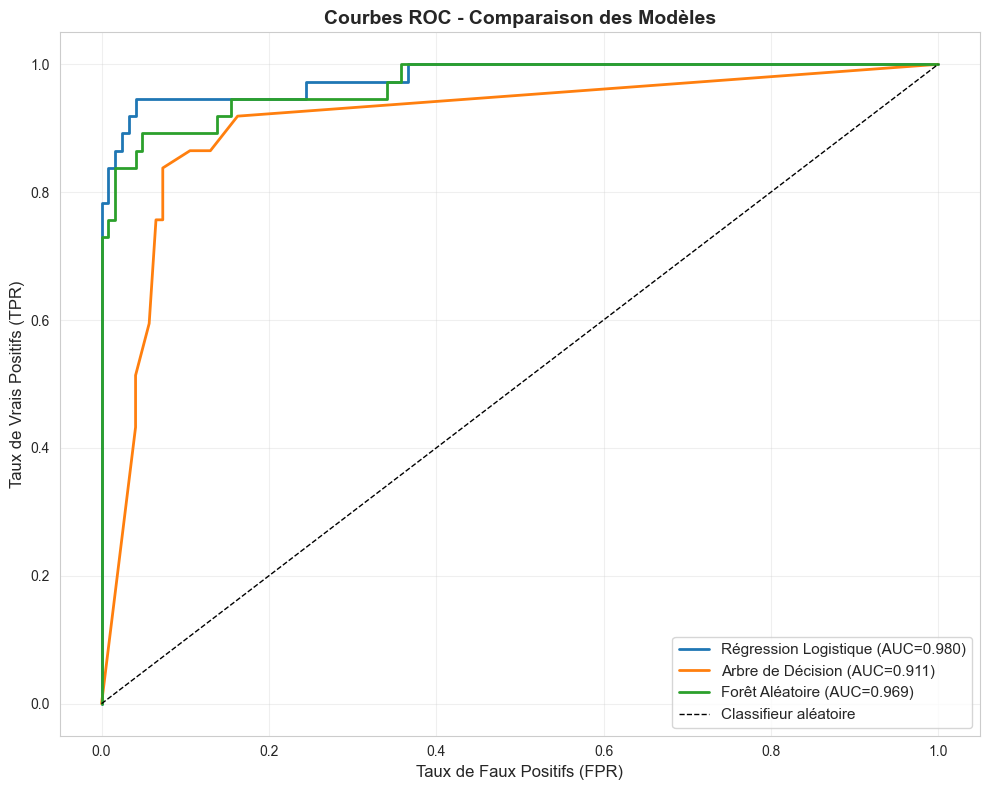

In [ ]:
plt.figure(figsize=(10, 8))

roc_models = [
    ('Régression Logistique', results_lr),
    ('Arbre de Décision', results_dt),
    ('Forêt Aléatoire', results_rf),
    ('KNN', results_knn),
    ('Réseau de Neurones (MLP)', results_mlp)
]

for name, result in roc_models:
    fpr, tpr, _ = roc_curve(y_test, result['y_test_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={result['AUC_ROC']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Classifieur aléatoire', linewidth=1)

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Matrices de confusion

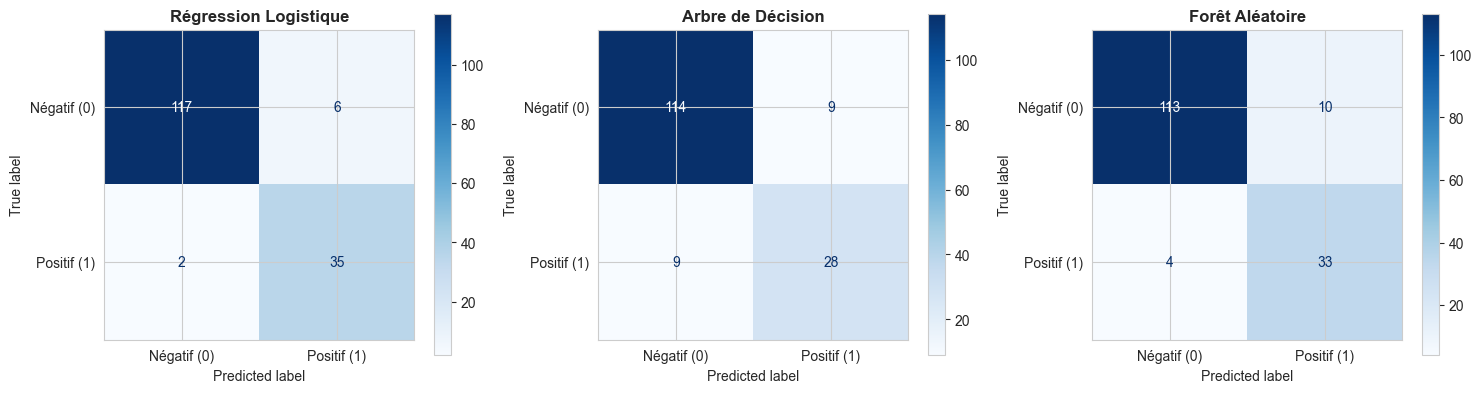

In [ ]:
models_info = [
    (results_lr, "Régression Logistique"),
    (results_dt, "Arbre de Décision"),
    (results_rf, "Forêt Aléatoire"),
    (results_knn, "KNN"),
    (results_mlp, "Réseau de Neurones (MLP)")
]

fig, axes = plt.subplots(1, len(models_info), figsize=(4.5 * len(models_info), 4))
if len(models_info) == 1:
    axes = [axes]

for ax, (result, name) in zip(axes, models_info):
    y_pred = result['y_test_pred']
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Négatif (0)', 'Positif (1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.5 Distribution des probabilités prédites

In [ ]:
models_proba = [
    (results_lr['y_test_pred_proba'], 'Régression Logistique'),
    (results_dt['y_test_pred_proba'], 'Arbre de Décision'),
    (results_rf['y_test_pred_proba'], 'Forêt Aléatoire'),
    (results_knn['y_test_pred_proba'], 'KNN'),
    (results_mlp['y_test_pred_proba'], 'Réseau de Neurones (MLP)')
]

fig, axes = plt.subplots(1, len(models_proba), figsize=(4 * len(models_proba), 5))
if len(models_proba) == 1:
    axes = [axes]

for ax, (proba, model_name) in zip(axes, models_proba):
    proba_class_0 = proba[y_test == 0]
    proba_class_1 = proba[y_test == 1]

    ax.hist(proba_class_0, bins=20, alpha=0.6, label='Pas de pathologie', color='#2ecc71', edgecolor='black')
    ax.hist(proba_class_1, bins=20, alpha=0.6, label='Pathologie présente', color='#e74c3c', edgecolor='black')

    ax.set_xlabel('Probabilité prédite', fontweight='bold', fontsize=10)
    ax.set_ylabel('Fréquence', fontweight='bold', fontsize=10)
    ax.set_title(model_name, fontweight='bold', fontsize=10)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Seuil de décision')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 INTERPRÉTATION - Histogramme des probabilités:")
print("• Classes bien séparées → modèle confiant")
print("• Chevauchement → modèle incertain entre les deux classes")
print("• Pics à 0.5 → modèle indécis pour ces exemples")

### 6.6 Importance des Features (Interprétabilité)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Feature importance - Arbre de Décision
feature_importance_dt = pd.DataFrame({
    'feature': range(X_train_transformed.shape[1]),
    'importance': model_dt.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

ax = axes[0]
ax.barh(range(len(feature_importance_dt)), feature_importance_dt['importance'], color='#3498db', alpha=0.7)
ax.set_yticks(range(len(feature_importance_dt)))
ax.set_yticklabels([f'Feature {i}' for i in feature_importance_dt['feature']], fontsize=9)
ax.set_xlabel('Score d\'importance', fontweight='bold', fontsize=10)
ax.set_title('Arbre de Décision - Top 10 Features', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)

# Feature importance - Forêt Aléatoire
feature_importance_rf = pd.DataFrame({
    'feature': range(X_train_transformed.shape[1]),
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

ax = axes[1]
ax.barh(range(len(feature_importance_rf)), feature_importance_rf['importance'], color='#e74c3c', alpha=0.7)
ax.set_yticks(range(len(feature_importance_rf)))
ax.set_yticklabels([f'Feature {i}' for i in feature_importance_rf['feature']], fontsize=9)
ax.set_xlabel('Score d\'importance', fontweight='bold', fontsize=10)
ax.set_title('Forêt Aléatoire - Top 10 Features', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("🔍 INTERPRÉTATION - Importance des Features:")
print("• Features avec score élevé = critiques pour la prédiction")
print("• Features avec score faible = peu contributifs au modèle")
print("• Comparaison DT vs RF = consensus sur l'importance des variables")
print(f"\nVariables les plus importantes (Random Forest):")
for idx, row in feature_importance_rf.iterrows():
    print(f"  Feature {int(row['feature'])}: {row['importance']:.4f}")

### 6.7 Courbes d'Apprentissage (Diagnostic Bias-Variance)

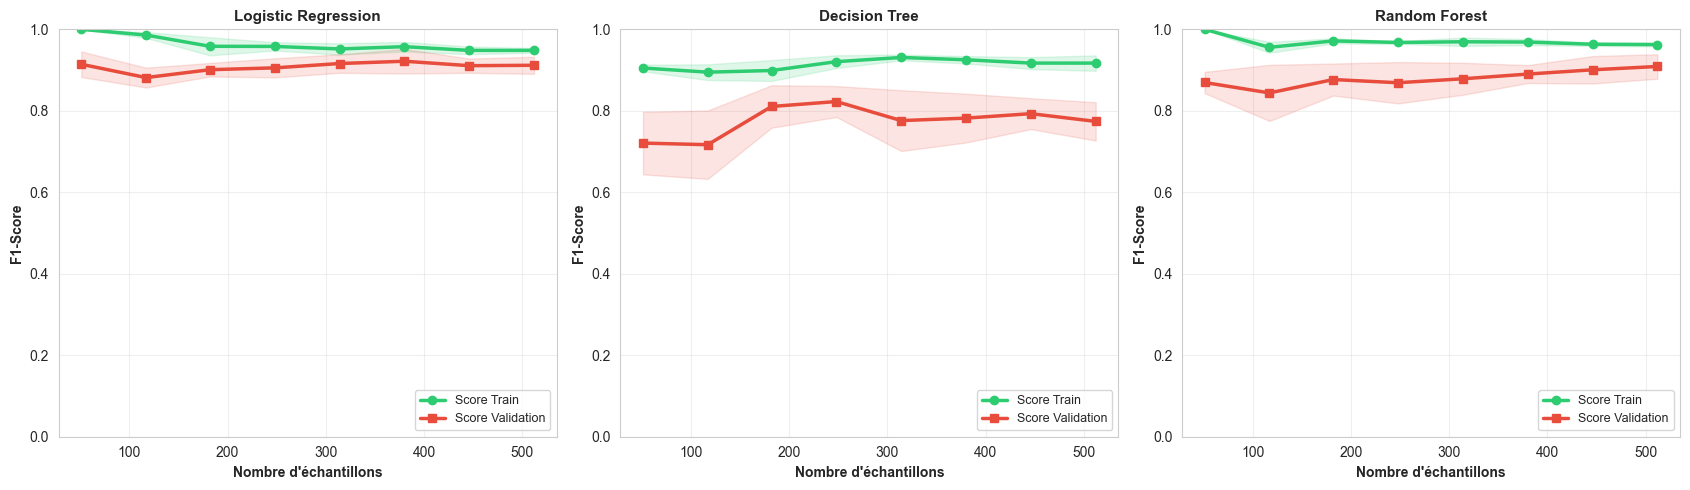

📈 DIAGNOSTIC BIAS-VARIANCE:
• Gap faible (train ≈ validation) = bon équilibre ✓
• Gap large (train >> validation) = SUR-APPRENTISSAGE (high variance) ⚠️
• Train bas ET validation bas = SOUS-APPRENTISSAGE (high bias) 🔴
• Courbes qui convergent jusqu'à 100% = données suffisantes


In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, model_name, ax):
    """Trace la courbe d'apprentissage d'un modèle"""
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='f1', n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', label='Score Train', linewidth=2.5, color='#2ecc71', markersize=6)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2ecc71')

    ax.plot(train_sizes, val_mean, 's-', label='Score Validation', linewidth=2.5, color='#e74c3c', markersize=6)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')

    ax.set_xlabel('Nombre d\'échantillons', fontweight='bold', fontsize=10)
    ax.set_ylabel('F1-Score', fontweight='bold', fontsize=10)
    ax.set_title(model_name, fontweight='bold', fontsize=10)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

learning_models = [
    (model_lr, X_train_transformed, y_train, 'Logistic Regression'),
    (model_dt, X_train_transformed, y_train, 'Decision Tree'),
    (model_rf, X_train_transformed, y_train, 'Random Forest'),
    (model_knn, X_train_transformed, y_train, 'KNN'),
    (model_mlp, X_train_transformed, y_train, 'Réseau de Neurones (MLP)')
]

fig, axes = plt.subplots(1, len(learning_models), figsize=(4 * len(learning_models), 5))
if len(learning_models) == 1:
    axes = [axes]

for ax, (model, X_data, y_data, label) in zip(axes, learning_models):
    plot_learning_curve(model, X_data, y_data, label, ax)

plt.tight_layout()
plt.show()

print("📈 DIAGNOSTIC BIAS-VARIANCE:")
print("• Gap faible (train ≈ validation) = bon équilibre")
print("• Gap large (train >> validation) = sur-apprentissage")
print("• Train bas ET validation bas = sous-apprentissage")
print("• Courbes qui convergent = quantité de données suffisante")

### 6.8 Analyse Comparative: Train vs Test

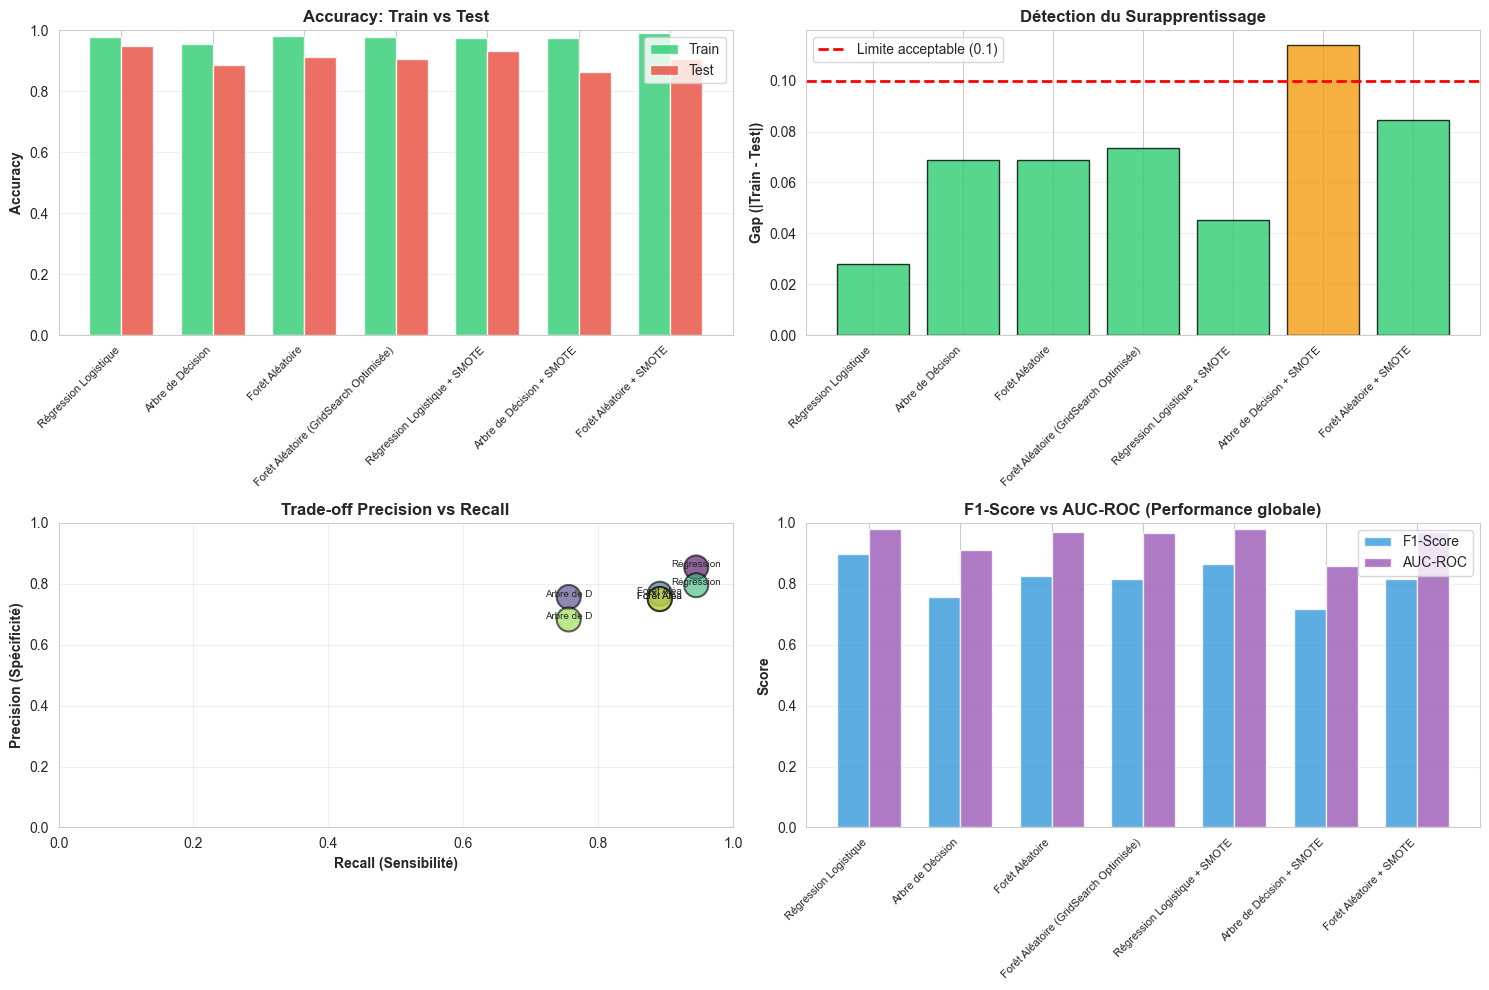

📊 SYNTHÈSE VISUELLE:
1. Train vs Test: Écarts importants signalent du surapprentissage
2. Gap d'Overfitting: Bar rouge = danger, bar verte = modèle stable
3. Precision-Recall: Position idéale = coin supérieur droit
4. F1 vs AUC: Métriques complémentaires pour l'évaluation globale


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

models_list = comparison_df['Model'].tolist()
x_pos = np.arange(len(models_list))

# 1. Train vs Test Accuracy
ax = axes[0, 0]
width = 0.35
ax.bar(x_pos - width/2, comparison_df['Train_Accuracy'], width, label='Train', alpha=0.8, color='#2ecc71')
ax.bar(x_pos + width/2, comparison_df['Test_Accuracy'], width, label='Test', alpha=0.8, color='#e74c3c')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Accuracy: Train vs Test', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels([m.replace('_', '\n') for m in models_list], fontsize=8, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

# 2. Surapprentissage (Overfitting Gap)
ax = axes[0, 1]
colors_overfit = ['#2ecc71' if gap < 0.1 else '#f39c12' if gap < 0.15 else '#e74c3c' 
                  for gap in comparison_df['Overfit_Gap']]
ax.bar(x_pos, comparison_df['Overfit_Gap'], color=colors_overfit, alpha=0.8, edgecolor='black')
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='Limite acceptable (0.1)')
ax.set_ylabel('Gap (|Train - Test|)', fontweight='bold')
ax.set_title('Détection du Surapprentissage', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels([m.replace('_', '\n') for m in models_list], fontsize=8, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Precision vs Recall
ax = axes[1, 0]
ax.scatter(comparison_df['Recall'], comparison_df['Precision'], s=300, alpha=0.6, 
          c=range(len(comparison_df)), cmap='viridis', edgecolors='black', linewidth=1.5)
for idx, model_name in enumerate(models_list):
    ax.annotate(model_name[:10], 
               (comparison_df.iloc[idx]['Recall'], comparison_df.iloc[idx]['Precision']),
               fontsize=7, ha='center')
ax.set_xlabel('Recall (Sensibilité)', fontweight='bold')
ax.set_ylabel('Precision (Spécificité)', fontweight='bold')
ax.set_title('Trade-off Precision vs Recall', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# 4. F1-Score vs AUC-ROC
ax = axes[1, 1]
width = 0.35
ax.bar(x_pos - width/2, comparison_df['F1_Score'], width, label='F1-Score', alpha=0.8, color='#3498db')
ax.bar(x_pos + width/2, comparison_df['AUC_ROC'], width, label='AUC-ROC', alpha=0.8, color='#9b59b6')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('F1-Score vs AUC-ROC (Performance globale)', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels([m.replace('_', '\n') for m in models_list], fontsize=8, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("📊 SYNTHÈSE VISUELLE:")
print("1. Train vs Test: Écarts importants signalent du surapprentissage")
print("2. Gap d'Overfitting: Bar rouge = danger, bar verte = modèle stable")
print("3. Precision-Recall: Position idéale = coin supérieur droit")
print("4. F1 vs AUC: Métriques complémentaires pour l'évaluation globale")

---
## 7. ANALYSE CRITIQUE ET RÉSULTATS

### 7.1 Analyse complète

In [ ]:
print("ANALYSE CLINIQUE ET D'INTERPRÉTATION")
print("="*80)

print("\n1. DÉSÉQUILIBRE DES CLASSES:")
class_0_pct = (y==0).sum()/len(y)*100
class_1_pct = (y==1).sum()/len(y)*100
print(f"   - Absence de pathologie (0): {class_0_pct:.1f}%")
print(f"   - Présence de pathologie (1): {class_1_pct:.1f}%")
print(f"   - Imbalancement: {abs(class_0_pct - class_1_pct):.1f}%")
if abs(class_0_pct - class_1_pct) > 20:
    print(f"   ⚠️  DÉSÉQUILIBRE SIGNIFICATIF - F1-score plus pertinent qu'Accuracy")

print("\n2. MEILLEUR MODÈLE:")
best_idx = comparison_df['F1_Score'].idxmax()
best_model_name = comparison_df.iloc[best_idx]['Model']
print(f"   {best_model_name}")

print("\n3. SURAPPRENTISSAGE:")
for idx, row in comparison_df.iterrows():
    gap = row['Overfit_Gap']
    status = "⚠️  ÉLEVÉ" if gap > 0.1 else "✓ Acceptable"
    print(f"   {row['Model']}: {gap:.4f} {status}")

print("\n" + "="*80)

ANALYSE CLINIQUE ET D'INTERPRÉTATION

1. DÉSÉQUILIBRE DES CLASSES:
   - Absence de pathologie (0): 76.8%
   - Présence de pathologie (1): 23.2%
   - Imbalancement: 53.5%
   ⚠️  DÉSÉQUILIBRE SIGNIFICATIF - F1-score plus pertinent qu'Accuracy

2. MEILLEUR MODÈLE:
   Régression Logistique

3. SURAPPRENTISSAGE:
   Régression Logistique: 0.0281 ✓ Acceptable
   Arbre de Décision: 0.0688 ✓ Acceptable
   Forêt Aléatoire: 0.0687 ✓ Acceptable



### 7.2 Rapport du meilleur modèle

In [ ]:
best_idx = comparison_df['F1_Score'].idxmax()
best_result = comparison_df.loc[best_idx]
best_model_name = best_result['Model']

model_results_map = {
    results_lr['Model']: results_lr,
    results_dt['Model']: results_dt,
    results_rf['Model']: results_rf,
    results_knn['Model']: results_knn,
    results_mlp['Model']: results_mlp
}

# Ajouter les modèles optionnels si présents
for optional_result_name in ['results_rf_optimized', 'results_lr_smote', 'results_dt_smote', 'results_rf_smote']:
    if optional_result_name in globals():
        optional_result = globals()[optional_result_name]
        model_results_map[optional_result['Model']] = optional_result

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print("="*80)

y_best_pred = model_results_map[best_model_name]['y_test_pred']
print("\nRAPPORT DE CLASSIFICATION:")
print(classification_report(y_test, y_best_pred,
                           target_names=['Pas de pathologie', 'Pathologie présente']))

print("ANALYSE À COMPLÉTER:")
print("- Justifiez pourquoi ce modèle est le meilleur")
print("- Analysez les forces et faiblesses")
print("- Commentez les implications cliniques")


🏆 MEILLEUR MODÈLE: Régression Logistique

RAPPORT DE CLASSIFICATION:
                     precision    recall  f1-score   support

  Pas de pathologie       0.98      0.95      0.97       123
Pathologie présente       0.85      0.95      0.90        37

           accuracy                           0.95       160
          macro avg       0.92      0.95      0.93       160
       weighted avg       0.95      0.95      0.95       160

ANALYSE À COMPLÉTER:
- Justifiez pourquoi ce modèle est le meilleur
- Analysez les forces et faiblesses
- Commentez les implications cliniques


---
## 8. CONCLUSIONS

### Résumé et recommandations

[À COMPLÉTER]

### Limitations

[À COMPLÉTER]

### Améliorations futures

[À COMPLÉTER]